In [1]:
%load_ext autoreload
%autoreload 2

import os
import tempfile

from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F



In [2]:
import colapy


def extract_nucleons_numpy(particles: list[Any]) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Match ``datasets.data_io.extract_nucleons_numpy``: ``pos`` is ``(N, 4)`` as ``(t, x, y, z)`` (fm/c, fm)."""
    pos, mom, is_proton = [], [], []
    for p in particles:
        if p.pdg_code == 2212:
            mom.append([p.momentum.e, p.momentum.x, p.momentum.y, p.momentum.z])
            pos.append([p.position.t, p.position.x, p.position.y, p.position.z])
            is_proton.append(True)
        elif p.pdg_code == 2112:
            mom.append([p.momentum.e, p.momentum.x, p.momentum.y, p.momentum.z])
            pos.append([p.position.t, p.position.x, p.position.y, p.position.z])
            is_proton.append(False)
    if not pos:
        return np.zeros((0, 4), np.float64), np.zeros((0, 4), np.float64), np.zeros((0,), bool)
    return np.asarray(pos, np.float64), np.asarray(mom, np.float64), np.asarray(is_proton, bool)


class W(colapy.WriterBase):
    events = []

    def __init__(self, **kwargs):
        self.events.clear()

    def __call__(self, event_data):
        self.events.append(event_data)

def try_make_urqmd_event_generator():
    CONFIG = """
<?xml version="1.0" encoding="UTF-8" ?>
<program>
    <generator name="URQMDGenerator"
        pro="197 79"
        tar="197 79"
        nev="1"
        imp="5."
        elb="100."
        tim="200 200"
        generated_config_file="input_file"/>
    <writer name="PythonWriter" class="W"/>
</program>
"""

    def gen_one():
        with tempfile.NamedTemporaryFile(mode="w", suffix=".xml", delete_on_close=False) as tmp:
            tmp.write(CONFIG)
            tmp.close()
            rm = colapy.RunManager().load_module("COLA-Py").load_module("COLA_UrQMD").load_config(file=tmp.name)
            rm.run(1)
            if os.path.exists("input_file"):
                os.remove("input_file")
        if not W.events:
            return np.zeros((0, 4)), np.zeros((0, 4)), np.zeros((0,), bool)
        ev = W.events[-1]
        pos, mom, isp = extract_nucleons_numpy(ev.particles)
        return pos, mom, isp

    return gen_one


URQMD_GEN = try_make_urqmd_event_generator()


## Baseline clustering: Coalescence


In [3]:
from pathlib import Path

import numpy as np

from cluster_energy import partition_loss_numpy
from models import (
    Q_CUT_MEVC,
    R_CUT_FM,
    baseline_clusters_numpy,
    load_valid_events_from_pkl,
)


def baseline_labels_and_partition(
    pos: np.ndarray,
    mom: np.ndarray,
    isp: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, list[list[int]]]:
    """Align lengths; return (pos_n, mom_n, isp_n, baseline_partition)."""
    n0 = min(pos.shape[0], mom.shape[0], isp.shape[0])
    pos_n = np.asarray(pos[:n0], dtype=np.float64)
    mom_n = np.asarray(mom[:n0], dtype=np.float64)
    isp_n = np.asarray(isp[:n0], dtype=bool)
    n = pos_n.shape[0]
    if n < 2:
        return pos_n, mom_n, isp_n, []
    part = baseline_clusters_numpy(pos_n, mom_n, list(range(n)), R_CUT_FM, Q_CUT_MEVC)
    return pos_n, mom_n, isp_n, part


def labels_from_partition(n: int, part: list[list[int]]) -> np.ndarray:
    lab = np.zeros(n, dtype=np.int32)
    for ci, c in enumerate(part):
        for j in c:
            lab[j] = ci
    return lab


def benchmark_baseline_on_events(
    events: list[tuple[np.ndarray, np.ndarray, np.ndarray]],
) -> None:
    l_list: list[float] = []
    for pos, mom, isp in events:
        n = pos.shape[0]
        if n < 2:
            continue
        part = baseline_clusters_numpy(pos, mom, list(range(n)), R_CUT_FM, Q_CUT_MEVC)
        l_list.append(float(partition_loss_numpy(pos, mom, isp, part)))
    if not l_list:
        print("No events with n≥2 in slice.")
        return
    l_mev = np.asarray(l_list, dtype=np.float64)
    n_in = len(events)
    print(
        f"Baseline (slice len={n_in}, evaluated n = {len(l_list)}): "
        f"partition loss = {l_mev.mean():.1f} ± {l_mev.std():.1f} MeV"
    )


_VALID_EVENTS = load_valid_events_from_pkl(Path("datasets") / "urqmd_nucleons_1k" / "dataset.pkl")


/Users/artyasen/.pyenv/versions/3.12.4/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
benchmark_baseline_on_events(_VALID_EVENTS[:64])


Baseline (slice len=64, evaluated n = 64): partition loss = -165.1 ± 229.2 MeV


## Baseline clustering: Visualization


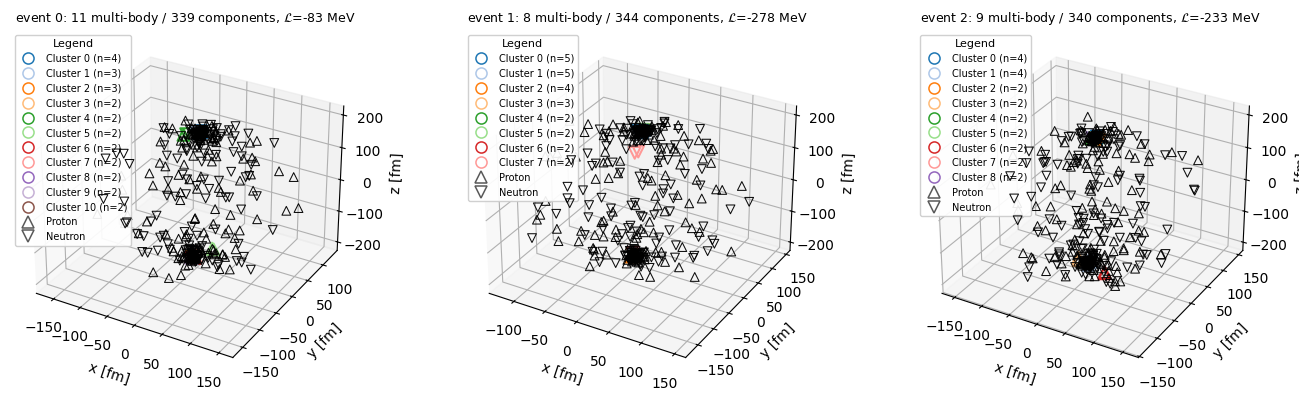

In [5]:
from matplotlib.lines import Line2D


def _tab20_sample(i: int) -> tuple:
    """Distinct ``tab20`` color for multi-body cluster rank ``i`` (cycles every 20)."""
    cmap = plt.get_cmap("tab20")
    n = int(getattr(cmap, "N", 20))
    t = (float(i % n) + 0.5) / float(n)
    return cmap(t)


def plot_baseline_clusterings_preview(
    events: list[tuple[np.ndarray, np.ndarray, np.ndarray]],
    *,
    seed: int = 0,
) -> None:
    if not events:
        print("No events to visualize.")
        return
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(events), size=len(events), replace=False)
    ncols = min(3, len(events))
    nrows = int(np.ceil(len(events) / ncols))
    fig = plt.figure(figsize=(4.6 * ncols, 4.0 * nrows))
    z_back, z_front = 1, 25
    s_single, lw_single = 40, 0.75
    s_multi, lw_multi = 72, 1.45
    edge_w_leg = 1.1
    for j, ii in enumerate(idx):
        pos, mom, isp = events[int(ii)]
        pos_n, mom_n, isp_n, part = baseline_labels_and_partition(pos, mom, isp)
        n = pos_n.shape[0]
        ax = fig.add_subplot(nrows, ncols, j + 1, projection="3d")
        if n < 2 or not part:
            ax.set_title(f"event {int(ii)}: n<2 or empty", fontsize=9)
            continue
        lab = labels_from_partition(n, part)
        cluster_sizes = np.array([len(c) for c in part], dtype=int)
        singleton = cluster_sizes[lab] == 1
        L_part = float(partition_loss_numpy(pos_n, mom_n, isp_n, part))
        pr = isp_n
        ne = ~isp_n
        multi_ids = sorted(ci for ci, c in enumerate(part) if len(c) > 1)
        ci_to_rgba = {ci: _tab20_sample(rank) for rank, ci in enumerate(multi_ids)}
        # Background: singletons (draw first, smaller).
        for mask, marker in ((pr, "^"), (ne, "v")):
            ms = mask & singleton
            if np.any(ms):
                ax.scatter(
                    pos_n[ms, 0],
                    pos_n[ms, 1],
                    pos_n[ms, 2],
                    facecolors="none",
                    edgecolors="black",
                    marker=marker,
                    s=s_single,
                    linewidths=lw_single,
                    alpha=0.95,
                    zorder=z_back,
                    depthshade=True,
                )
        # Foreground: multi-body clusters (draw last, larger, no depth fade).
        for mask, marker in ((pr, "^"), (ne, "v")):
            mm = mask & ~singleton
            if np.any(mm):
                idx_mm = np.flatnonzero(mm)
                ec = np.array([ci_to_rgba[int(lab[i])] for i in idx_mm], dtype=float)
                ax.scatter(
                    pos_n[mm, 0],
                    pos_n[mm, 1],
                    pos_n[mm, 2],
                    facecolors="none",
                    edgecolors=ec,
                    marker=marker,
                    s=s_multi,
                    linewidths=lw_multi,
                    alpha=1.0,
                    zorder=z_front,
                    depthshade=False,
                )
        ax.set_xlabel("x [fm]")
        ax.set_ylabel("y [fm]")
        ax.set_zlabel("z [fm]")
        n_multi = int(np.sum(cluster_sizes > 1))
        ax.set_title(
            rf"event {int(ii)}: {n_multi} multi-body / {len(part)} components, "
            rf"$\mathcal{{L}}$={L_part:.0f} MeV",
            fontsize=9,
        )
        handles: list[Line2D] = []
        for ci in multi_ids:
            rgba = ci_to_rgba[ci]
            handles.append(
                Line2D(
                    [0],
                    [0],
                    linestyle="none",
                    marker="o",
                    markersize=8.0,
                    markerfacecolor="none",
                    markeredgecolor=rgba,
                    markeredgewidth=edge_w_leg,
                    label=f"Cluster {ci} (n={len(part[ci])})",
                )
            )
        handles.append(
            Line2D(
                [0],
                [0],
                linestyle="none",
                marker="^",
                markersize=8.0,
                markerfacecolor="none",
                markeredgecolor="0.35",
                markeredgewidth=edge_w_leg,
                label="Proton",
            )
        )
        handles.append(
            Line2D(
                [0],
                [0],
                linestyle="none",
                marker="v",
                markersize=8.0,
                markerfacecolor="none",
                markeredgecolor="0.35",
                markeredgewidth=edge_w_leg,
                label="Neutron",
            )
        )
        ax.legend(
            handles=handles,
            loc="upper left",
            fontsize=7,
            framealpha=0.92,
            title="Legend",
            title_fontsize=8,
        )
    plt.tight_layout()
    plt.show()


plot_baseline_clusterings_preview(_VALID_EVENTS[:3], seed=1)


## Supervised on baseline: KNN graph


In [6]:
from pathlib import Path
from datetime import datetime

import numpy as np

from training.utils import make_event_sampler

TB_NOTEBOOK_ROOT = Path("runs")
TB_SESSION_DIR = TB_NOTEBOOK_ROOT / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
TB_SESSION_DIR.mkdir(parents=True, exist_ok=True)

EVENT_SAMPLER = make_event_sampler(
    events=_VALID_EVENTS, rng=np.random.default_rng(42), fallback_urqmd=None
)

# Validation subset for TensorBoard (slice here to cap validation cost).
VAL_TENSORBOARD_EVENTS = _VALID_EVENTS[:256]


In [7]:
%load_ext tensorboard

In [ ]:
from models import (
    AffinityGraphEnv,
    CoalescenceHeuristicModel,
    GAT_NODE_IN_DIM,
    GATAffinityPolicy,
    KNNGraphBuilder,
)
from training.supervised import train_supervised_edges
from training.tensorboard import TensorBoardHistoryLogger

supervised_env = AffinityGraphEnv(KNNGraphBuilder(k=4), CoalescenceHeuristicModel())
supervised_policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    edge_mlp_depth=2,
)
tb_sup_knn = TensorBoardHistoryLogger(TB_SESSION_DIR / "supervised_knn6")
try:
    sup_hist = train_supervised_edges(
        supervised_policy,
        supervised_env,
        EVENT_SAMPLER,
        steps=101,
        events_per_step=8,
        lr=1e-3,
        focal_gamma=2.0,
        pos_weight=20,
        val_events=VAL_TENSORBOARD_EVENTS,
        on_update=tb_sup_knn.log_supervised,
        best_val_checkpoint_path=TB_SESSION_DIR / "supervised_knn6" / "best_val_physics.pt",
        n_val_steps=25,
    )
finally:
    tb_sup_knn.close()
print(
    "last partition loss (MeV):",
    sup_hist["pretrain_partition_loss"][-1],
    "| recall@0.5:",
    sup_hist["pretrain_pos_recall_05"][-1],
)


SupEdges:   1%|          | 1/101 [00:13<22:19, 13.40s/it, partition_gev=13.7, baseline_gev=-0.304, bce=0.171, positive_recall=0, frac_edges_pred_on=0.0625]

[val] step=0 L_pos=0.3035 L_base=-0.1414 (GeV) n=256


SupEdges:  26%|██▌       | 26/101 [00:37<05:35,  4.47s/it, partition_gev=-0.714, baseline_gev=-0.248, bce=0.0834, positive_recall=0.767, frac_edges_pred_on=0.127] 

[val] step=25 L_pos=-2.473 L_base=-0.1414 (GeV) n=256


SupEdges:  50%|█████     | 51/101 [01:04<04:01,  4.83s/it, partition_gev=-2.43, baseline_gev=-0.096, bce=0.0524, positive_recall=0.938, frac_edges_pred_on=0.0901]  

[val] step=50 L_pos=-3.734 L_base=-0.1414 (GeV) n=256


SupEdges:  75%|███████▌  | 76/101 [01:31<02:03,  4.93s/it, partition_gev=-5.09, baseline_gev=-0.151, bce=0.0416, positive_recall=0.991, frac_edges_pred_on=0.108]  

[val] step=75 L_pos=-2.067 L_base=-0.1414 (GeV) n=256


SupEdges: 100%|██████████| 101/101 [01:58<00:00,  1.17s/it, partition_gev=-2.32, baseline_gev=-0.596, bce=0.0347, positive_recall=0.919, frac_edges_pred_on=0.072] 

[val] step=100 L_pos=-2.363 L_base=-0.1414 (GeV) n=256
last partition loss (MeV): -2315.3066820116055 | recall@0.5: 0.9193828881328882


## Supervised on baseline: radius graph

In [ ]:
from models import (
    AffinityGraphEnv,
    CoalescenceHeuristicModel,
    GAT_NODE_IN_DIM,
    GATAffinityPolicy,
    RadiusGraphBuilder,
)
from training.supervised import train_supervised_edges
from training.tensorboard import TensorBoardHistoryLogger

radius_env = AffinityGraphEnv(RadiusGraphBuilder(radius_norm=2.0), CoalescenceHeuristicModel())
radius_policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    edge_mlp_depth=2,
)

tb_sup_radius = TensorBoardHistoryLogger(TB_SESSION_DIR / "supervised_radius_115")
try:
    radius_hist = train_supervised_edges(
        radius_policy,
        radius_env,
        EVENT_SAMPLER,
        steps=101,
        events_per_step=8,
        lr=1e-3,
        focal_gamma=2.0,
        pos_weight=20,
        val_events=VAL_TENSORBOARD_EVENTS,
        on_update=tb_sup_radius.log_supervised,
        best_val_checkpoint_path=TB_SESSION_DIR / "supervised_radius_115" / "best_val_physics.pt",
        n_val_steps=25,
    )
finally:
    tb_sup_radius.close()
print(
    "radius r=1.15 | last partition loss (MeV):",
    radius_hist["pretrain_partition_loss"][-1],
    "| recall@0.5:",
    radius_hist["pretrain_pos_recall_05"][-1],
)


SupEdges:   1%|          | 1/101 [00:14<24:26, 14.67s/it, partition_gev=-2.45, baseline_gev=-0.142, bce=0.171, positive_recall=0.493, frac_edges_pred_on=0.531]

[val] step=0 L_pos=-3.178 L_base=-0.1414 (GeV) n=256


SupEdges:  26%|██▌       | 26/101 [00:40<05:53,  4.71s/it, partition_gev=-5.47, baseline_gev=-0.255, bce=0.126, positive_recall=1, frac_edges_pred_on=1]       

[val] step=25 L_pos=-3.178 L_base=-0.1414 (GeV) n=256


SupEdges:  50%|█████     | 51/101 [01:06<03:58,  4.77s/it, partition_gev=-2.82, baseline_gev=-0.104, bce=0.144, positive_recall=1, frac_edges_pred_on=1]  

[val] step=50 L_pos=-3.178 L_base=-0.1414 (GeV) n=256


SupEdges:  75%|███████▌  | 76/101 [01:31<01:57,  4.71s/it, partition_gev=-2.94, baseline_gev=-0.118, bce=0.122, positive_recall=1, frac_edges_pred_on=1] 

[val] step=75 L_pos=-3.178 L_base=-0.1414 (GeV) n=256


SupEdges: 100%|██████████| 101/101 [01:57<00:00,  1.16s/it, partition_gev=-2.65, baseline_gev=-0.0769, bce=0.113, positive_recall=1, frac_edges_pred_on=1]  

[val] step=100 L_pos=-3.178 L_base=-0.1414 (GeV) n=256
radius r=1.15 | last partition loss (MeV): -2650.3697349126983 | recall@0.5: 1.0


## Supervised on baseline: full graph

In [ ]:
from models import (
    AffinityGraphEnv,
    CoalescenceHeuristicModel,
    FullGraphBuilder,
    GAT_NODE_IN_DIM,
    GATAffinityPolicy,
)
from training.supervised import train_supervised_edges
from training.tensorboard import TensorBoardHistoryLogger


full_env = AffinityGraphEnv(FullGraphBuilder(), CoalescenceHeuristicModel())
full_policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    edge_mlp_depth=2,
)

tb_sup_full = TensorBoardHistoryLogger(TB_SESSION_DIR / "supervised_full")
try:
    full_hist = train_supervised_edges(
        full_policy,
        full_env,
        EVENT_SAMPLER,
        steps=101,
        events_per_step=8,
        lr=1e-3,
        focal_gamma=2.0,
        pos_weight=15,
        val_events=VAL_TENSORBOARD_EVENTS,
        on_update=tb_sup_full.log_supervised,
        best_val_checkpoint_path=TB_SESSION_DIR / "supervised_full" / "best_val_physics.pt",
        n_val_steps=25,
    )
finally:
    tb_sup_full.close()
print(
    "full graph | last partition loss (MeV):",
    full_hist["pretrain_partition_loss"][-1],
    "| recall@0.5:",
    full_hist["pretrain_pos_recall_05"][-1],
)


SupEdges:   1%|          | 1/101 [00:23<39:55, 23.95s/it, partition_gev=253, baseline_gev=-0.0289, bce=0.0967, positive_recall=0.454, frac_edges_pred_on=0.0404]

[val] step=0 L_pos=0.132 L_base=-0.1414 (GeV) n=256


SupEdges:  26%|██▌       | 26/101 [01:18<09:59,  7.99s/it, partition_gev=0, baseline_gev=-0.093, bce=0.00227, positive_recall=0, frac_edges_pred_on=0]          

[val] step=25 L_pos=0 L_base=-0.1414 (GeV) n=256


SupEdges:  50%|█████     | 51/101 [02:12<06:42,  8.05s/it, partition_gev=-0.234, baseline_gev=-0.202, bce=0.00174, positive_recall=0.45, frac_edges_pred_on=0.000135]   

[val] step=50 L_pos=-0.04577 L_base=-0.1414 (GeV) n=256


SupEdges:  75%|███████▌  | 76/101 [03:08<03:31,  8.46s/it, partition_gev=-0.799, baseline_gev=-0.309, bce=0.00126, positive_recall=0.624, frac_edges_pred_on=0.000393] 

[val] step=75 L_pos=-0.3163 L_base=-0.1414 (GeV) n=256


SupEdges: 100%|██████████| 101/101 [04:06<00:00,  2.44s/it, partition_gev=-1.59, baseline_gev=-0.0569, bce=0.000947, positive_recall=0.942, frac_edges_pred_on=0.000909]

[val] step=100 L_pos=-1.722 L_base=-0.1414 (GeV) n=256
full graph | last partition loss (MeV): -1593.6115793392403 | recall@0.5: 0.9418094758064516


## RL: REINFORCE


In [11]:
import torch.optim as optim

from training.schedulers import CosineAnnealingWarmRestartsDecayMax

from models import (
    AffinityGraphEnv,
    CoalescenceHeuristicModel,
    GAT_NODE_IN_DIM,
    GATAffinityPolicy,
    KNNGraphBuilder,
)
from training.reinforce import train_reinforce
from training.tensorboard import TensorBoardHistoryLogger

In [ ]:
env = AffinityGraphEnv(
    KNNGraphBuilder(k=4),
    CoalescenceHeuristicModel(),
    cluster_dissolve_energy_threshold_mev=0,
)
policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    edge_mlp_depth=2,
)
train_supervised_edges(
    policy,
    env,
    EVENT_SAMPLER,
    steps=80,
    events_per_step=8,
    lr=1e-3,
    focal_gamma=2.0,
    pos_weight=20,
    val_events=VAL_TENSORBOARD_EVENTS,
    n_val_steps=50,
)

N_UPDATES = 1200
LR = 3e-4

train_opt = optim.Adam(policy.parameters(), lr=LR)
train_sched = CosineAnnealingWarmRestartsDecayMax(
    train_opt,
    T_0=max(1, N_UPDATES // 2),
    T_mult=1,
    eta_min=min(1e-6, max(1e-10, float(LR) * 0.01)),
    restart_eta_scale=0.2,
)

tb_rf = TensorBoardHistoryLogger(TB_SESSION_DIR / "reinforce")
try:
    history = train_reinforce(
        policy,
        env,
        EVENT_SAMPLER,
        optimizer=train_opt,
        lr_scheduler=train_sched,
        n_updates=N_UPDATES,
        episodes_per_update=32,
        ent_coef=0.02,
        max_grad_norm=1.2,
        policy_coef=1,
        rl_action_mode="bernoulli",
        val_events=VAL_TENSORBOARD_EVENTS,
        on_update=tb_rf.log_reinforce,
        n_val_steps=50,
        best_val_checkpoint_path=TB_SESSION_DIR / "reinforce" / "best_val_physics.pt",
    )
finally:
    tb_rf.close()


SupEdges:   1%|▏         | 1/80 [00:13<17:10, 13.05s/it, partition_gev=0, baseline_gev=-0.184, bce=0.161, positive_recall=0, frac_edges_pred_on=0.00234]

[val] step=0 L_pos=0 L_base=-0.1414 (GeV) n=256


SupEdges:  32%|███▎      | 26/80 [00:38<04:09,  4.62s/it, partition_gev=-4.01, baseline_gev=-0.293, bce=0.084, positive_recall=0.955, frac_edges_pred_on=0.217]     

[val] step=25 L_pos=-3.066 L_base=-0.1414 (GeV) n=256


SupEdges:  64%|██████▍   | 51/80 [01:06<02:31,  5.23s/it, partition_gev=-3.33, baseline_gev=-0.21, bce=0.0546, positive_recall=0.953, frac_edges_pred_on=0.0791]  

...

REINFORCE:  96%|█████████▌| 1151/1200 [55:48<05:30,  6.75s/it, partition_gev=-4.72, baseline_gev=-0.162, policy_loss=126, entropy=0.25, lr=1.36e-5, mean_return_gev=4.72, mean_episode_return_gev=4.72, mean_clusters=304]  

[val] update=1150 L_pos=-4.829 L_base=-0.1414 (GeV) n=256


REINFORCE:  98%|█████████▊| 1176/1200 [56:58<02:44,  6.84s/it, partition_gev=-3.02, baseline_gev=-0.114, policy_loss=31.5, entropy=0.24, lr=1.09e-5, mean_return_gev=3.02, mean_episode_return_gev=3.02, mean_clusters=306]  

[val] update=1175 L_pos=-4.306 L_base=-0.1414 (GeV) n=256


REINFORCE: 100%|██████████| 1200/1200 [57:50<00:00,  2.89s/it, partition_gev=-2.79, baseline_gev=-0.18, policy_loss=18.2, entropy=0.242, lr=6.48e-5, mean_return_gev=2.79, mean_episode_return_gev=2.79, mean_clusters=304] 


## RL: A2C

In [13]:
from training.a2c import train_actor_critic
from training.tensorboard import TensorBoardHistoryLogger
from training.utils import ValueWarmupConfig
from training.supervised import train_supervised_edges


In [ ]:
import torch.optim as optim

from models import (
    AffinityGraphEnv,
    CoalescenceHeuristicModel,
    GAT_NODE_IN_DIM,
    GATAffinityActorCritic,
    GATAffinityPolicy,
    KNNGraphBuilder,
)
from training.schedulers import CosineAnnealingWarmRestartsDecayMax

env = AffinityGraphEnv(
    KNNGraphBuilder(k=4),
    CoalescenceHeuristicModel(),
    cluster_dissolve_energy_threshold_mev=0,
)
policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    edge_mlp_depth=2,
)
train_supervised_edges(
    policy,
    env,
    EVENT_SAMPLER,
    steps=80,
    events_per_step=8,
    lr=1e-3,
    focal_gamma=2.0,
    pos_weight=20,
    val_events=VAL_TENSORBOARD_EVENTS,
    n_val_steps=50,
)

ac = GATAffinityActorCritic(policy)

N_UPDATES = 1200
LR = 3e-4

train_opt = optim.Adam(ac.parameters(), lr=LR)
train_sched = CosineAnnealingWarmRestartsDecayMax(
    train_opt,
    T_0=max(1, N_UPDATES // 2),
    T_mult=1,
    eta_min=min(1e-6, max(1e-10, float(LR) * 0.01)),
    restart_eta_scale=0.2,
)

tb_a2c = TensorBoardHistoryLogger(TB_SESSION_DIR / "a2c")
try:
    history_a2c = train_actor_critic(
        ac,
        env,
        EVENT_SAMPLER,
        optimizer=train_opt,
        lr_scheduler=train_sched,
        n_updates=N_UPDATES,
        episodes_per_update=32,
        ent_coef=0.012,
        value_coef=0.5,
        max_grad_norm=1.2,
        policy_coef=1,
        center_adv=True,
        rl_action_mode="bernoulli",
        val_events=VAL_TENSORBOARD_EVENTS,
        on_update=lambda h: tb_a2c.log_actor_critic(h, algo="a2c"),
        detach_value_features=False,
        n_val_steps=50,
        best_val_checkpoint_path=TB_SESSION_DIR / "a2c" / "best_val_physics.pt",
        value_warmup=ValueWarmupConfig(steps=20, lr=1e-2),
    )
finally:
    tb_a2c.close()


SupEdges:   1%|▏         | 1/80 [00:13<17:10, 13.05s/it, partition_gev=-0.000159, baseline_gev=-0.178, bce=0.173, positive_recall=0.948, frac_edges_pred_on=0.603]

[val] step=0 L_pos=0 L_base=-0.1414 (GeV) n=256


SupEdges:  32%|███▎      | 26/80 [00:38<04:21,  4.85s/it, partition_gev=-4.73, baseline_gev=-0.331, bce=0.0863, positive_recall=0.741, frac_edges_pred_on=0.128]   

[val] step=25 L_pos=-2.543 L_base=-0.1414 (GeV) n=256


SupEdges:  64%|██████▍   | 51/80 [01:07<02:33,  5.29s/it, partition_gev=-1.79, baseline_gev=-0.132, bce=0.0618, positive_recall=0.864, frac_edges_pred_on=0.0563] 

...

A2C:  96%|█████████▌| 1151/1200 [56:48<05:46,  7.08s/it, partition_gev=-2.11, baseline_gev=-0.169, policy_loss=34.6, value_loss=2.04e+6, entropy=0.282, lr=1.36e-5, mean_V_gev=3.11, mean_return_gev=2.11, mean_clusters=311]

[val] update=1150 L_pos=-3.537 L_base=-0.1414 (GeV) n=256


A2C:  98%|█████████▊| 1176/1200 [58:01<02:49,  7.04s/it, partition_gev=-2, baseline_gev=-0.101, policy_loss=15.9, value_loss=2.14e+6, entropy=0.279, lr=1.09e-5, mean_V_gev=3.1, mean_return_gev=2, mean_clusters=315]        

[val] update=1175 L_pos=-3.618 L_base=-0.1414 (GeV) n=256


A2C: 100%|██████████| 1200/1200 [58:57<00:00,  2.95s/it, partition_gev=-3.69, baseline_gev=-0.129, policy_loss=35.1, value_loss=6.4e+6, entropy=0.282, lr=6.48e-5, mean_V_gev=3.11, mean_return_gev=3.69, mean_clusters=304] 


### RL: PPO

In [ ]:
from models import (
    AffinityGraphEnv,
    CoalescenceHeuristicModel,
    GAT_NODE_IN_DIM,
    GATAffinityActorCritic,
    GATAffinityPolicy,
    KNNGraphBuilder,
)
from training import ValueWarmupConfig, train_ppo
from training.supervised import train_supervised_edges
from training.tensorboard import TensorBoardHistoryLogger
import torch.optim as optim

from training.schedulers import CosineAnnealingWarmRestartsDecayMax


env = AffinityGraphEnv(
    KNNGraphBuilder(k=4),
    CoalescenceHeuristicModel(),
    cluster_dissolve_energy_threshold_mev=0,
)
policy = GATAffinityPolicy(
    in_dim=GAT_NODE_IN_DIM,
    hidden=64,
    n_heads=4,
    n_gat_layers=2,
    edge_mlp_depth=2,
)
train_supervised_edges(
    policy,
    env,
    EVENT_SAMPLER,
    steps=80,
    events_per_step=8,
    lr=1e-3,
    focal_gamma=2.0,
    pos_weight=20,
    val_events=VAL_TENSORBOARD_EVENTS,
    n_val_steps=50,
)

ac_ppo = GATAffinityActorCritic(policy)

N_UPDATES = 1200
LR = 3e-4

train_opt = optim.Adam(ac_ppo.parameters(), lr=LR)
train_sched = CosineAnnealingWarmRestartsDecayMax(
    train_opt,
    T_0=max(1, N_UPDATES // 2),
    T_mult=1,
    eta_min=min(1e-6, max(1e-10, float(LR) * 0.01)),
    restart_eta_scale=0.2,
)

tb_ppo = TensorBoardHistoryLogger(TB_SESSION_DIR / "ppo")
try:
    history_ppo = train_ppo(
        ac_ppo,
        env,
        EVENT_SAMPLER,
        optimizer=train_opt,
        lr_scheduler=train_sched,
        n_updates=N_UPDATES,
        episodes_per_update=32,
        ppo_epochs=2,
        clip_range=0.15,
        value_coef=0.005,
        ent_coef=0.02,
        policy_coef=1,
        max_grad_norm=1.2,
        normalize_advantage=False,
        detach_value_features=True,
        value_warmup=ValueWarmupConfig(steps=20, lr=1e-2),
        rl_action_mode="bernoulli",
        val_events=VAL_TENSORBOARD_EVENTS,
        on_update=lambda h: tb_ppo.log_actor_critic(h, algo="ppo"),
        n_val_steps=50,
        best_val_checkpoint_path=TB_SESSION_DIR / "ppo" / "best_val_physics.pt",
    )
finally:
    tb_ppo.close()


SupEdges:   1%|▏         | 1/80 [00:14<19:01, 14.46s/it, partition_gev=0, baseline_gev=-0.28, bce=0.186, positive_recall=0.477, frac_edges_pred_on=0.74]

[val] step=0 L_pos=-0.009176 L_base=-0.1414 (GeV) n=256


SupEdges:  32%|███▎      | 26/80 [00:39<04:10,  4.63s/it, partition_gev=-1.39, baseline_gev=-0.126, bce=0.0845, positive_recall=0.6, frac_edges_pred_on=0.0913]      

[val] step=25 L_pos=-0.9795 L_base=-0.1414 (GeV) n=256


SupEdges:  64%|██████▍   | 51/80 [01:06<02:30,  5.19s/it, partition_gev=-2.6, baseline_gev=-0.0274, bce=0.0561, positive_recall=0.935, frac_edges_pred_on=0.0924] 

...

PPO:  96%|█████████▌| 1151/1200 [58:14<05:36,  6.87s/it, partition_gev=-4.41, baseline_gev=-0.223, policy_loss=240, value_loss=6.65e+6, approx_kl=0.000979, clip_frac=0, entropy=0.195, lr=1.36e-5, mean_V_gev=4.66, mean_return_gev=4.41, mean_clusters=298]         

[val] update=1150 L_pos=-5.165 L_base=-0.1414 (GeV) n=256


PPO:  98%|█████████▊| 1176/1200 [59:27<02:44,  6.86s/it, partition_gev=-4.19, baseline_gev=-0.187, policy_loss=499, value_loss=7.59e+6, approx_kl=0.00511, clip_frac=0, entropy=0.193, lr=1.09e-5, mean_V_gev=4.69, mean_return_gev=4.19, mean_clusters=302]          

[val] update=1175 L_pos=-5.03 L_base=-0.1414 (GeV) n=256


PPO: 100%|██████████| 1200/1200 [1:00:23<00:00,  3.02s/it, partition_gev=-3.33, baseline_gev=-0.0649, policy_loss=1.31e+3, value_loss=3.43e+6, approx_kl=0.00287, clip_frac=0, entropy=0.187, lr=6.48e-5, mean_V_gev=4.64, mean_return_gev=3.33, mean_clusters=301]  
